## 6.2.1 BaselineCNN训练流程与单轮验证

在统一训练环境、损失函数、评价指标和优化超参数已经确定的基础上，本节构建 BaselineCNN 的完整训练与验证流程。

本节主要完成以下任务：

1. 读取 4.3.1 保存的训练集和验证集分层划分结果；
2. 重建与前序步骤一致的图像变换和 DataLoader；
3. 实例化参数量为 391,946 的 BaselineCNN；
4. 构建基于交叉熵损失的训练与验证函数；
5. 在真实 EuroSAT 图像批次上检查前向传播、反向传播和参数更新；
6. 使用少量训练批次执行训练流程冒烟测试；
7. 计算 Accuracy、Top-3 Accuracy、Macro-Precision、Macro-Recall 和 Macro-F1；
8. 验证模型检查点的保存、读取和前向输出一致性；
9. 为下一步 BaselineCNN 正式训练准备可直接复用的训练函数。

本节只验证训练程序是否正确，不使用少量批次的结果评价模型真实性能。

In [1]:
# ==========================================
# 6.2.1 基础导入、路径定位与结果目录
# ==========================================

# 必须在NumPy、PyTorch等数值库导入前设置
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8"
)

os.environ.setdefault(
    "PYTHONHASHSEED",
    "42"
)


import sys
import json
import math
import copy
import random
import warnings

from pathlib import Path
from datetime import datetime


import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

import torchvision
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from IPython.display import display


warnings.filterwarnings(
    "default"
)


# ------------------------------
# 限制PyTorch线程数量
# ------------------------------
torch.set_num_threads(
    1
)

try:
    torch.set_num_interop_threads(
        1
    )
except RuntimeError:
    pass


# ------------------------------
# 自动定位项目根目录
# ------------------------------
def find_project_root(
    start_path=None
):
    """
    从当前Notebook所在目录逐层向上搜索项目根目录。

    项目根目录需要同时包含：
    EuroSAT_RGB、models、notebooks和results。
    """

    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path).resolve()
    )

    candidate_paths = [
        current_path,
        *current_path.parents
    ]

    for candidate_path in candidate_paths:

        required_paths = [
            candidate_path / "EuroSAT_RGB",
            candidate_path / "models",
            candidate_path / "notebooks",
            candidate_path / "results"
        ]

        if all(
            path.exists()
            for path in required_paths
        ):
            return candidate_path

    raise FileNotFoundError(
        "未能自动定位项目根目录。\n"
        "请确认项目根目录同时包含："
        "EuroSAT_RGB、models、notebooks和results。"
    )


PROJECT_ROOT = find_project_root()


# ------------------------------
# 项目目录
# ------------------------------
DATA_DIR = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

NOTEBOOKS_DIR = (
    PROJECT_ROOT
    / "notebooks"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


# ------------------------------
# 前序配置目录
# ------------------------------
STEP_611_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.1_统一训练环境与随机性控制"
)

STEP_612_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.2_损失函数与评价指标"
)

STEP_613_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.3_训练超参数与优化器配置"
)


RUNTIME_CONFIG_PATH = (
    STEP_611_DIR
    / "07_统一训练环境配置.json"
)

EVALUATION_CONFIG_PATH = (
    STEP_612_DIR
    / "10_统一评价配置.json"
)

TRAINING_CONFIG_PATH = (
    STEP_613_DIR
    / "09_统一训练超参数配置.json"
)


# ------------------------------
# 当前步骤结果目录
# ------------------------------
STEP_OUTPUT_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.2.1_BaselineCNN训练流程与单轮验证"
)

STEP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------
# 中文字体
# ------------------------------
font_candidates = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans CN",
    "Arial Unicode MS"
]

available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

selected_font = next(
    (
        font_name
        for font_name in font_candidates
        if font_name in available_fonts
    ),
    None
)

if selected_font is not None:
    plt.rcParams[
        "font.sans-serif"
    ] = [
        selected_font
    ]

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300

plt.rcParams[
    "axes.titleweight"
] = "bold"

plt.rcParams[
    "axes.labelweight"
] = "bold"


# ------------------------------
# Pandas显示设置
# ------------------------------
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    180
)

pd.set_option(
    "display.max_colwidth",
    120
)


# ------------------------------
# 路径检查
# ------------------------------
directory_check_df = pd.DataFrame({
    "目录项目": [
        "项目根目录",
        "EuroSAT数据目录",
        "模型目录",
        "6.1.1运行环境配置",
        "6.1.2评价配置",
        "6.1.3训练配置",
        "本步骤输出目录"
    ],
    "绝对路径": [
        str(PROJECT_ROOT),
        str(DATA_DIR),
        str(MODELS_DIR),
        str(RUNTIME_CONFIG_PATH),
        str(EVALUATION_CONFIG_PATH),
        str(TRAINING_CONFIG_PATH),
        str(STEP_OUTPUT_DIR)
    ],
    "是否存在": [
        PROJECT_ROOT.exists(),
        DATA_DIR.exists(),
        MODELS_DIR.exists(),
        RUNTIME_CONFIG_PATH.exists(),
        EVALUATION_CONFIG_PATH.exists(),
        TRAINING_CONFIG_PATH.exists(),
        STEP_OUTPUT_DIR.exists()
    ]
})


print(
    "6.2.1项目路径定位完成。"
)

print(
    f"项目根目录：{PROJECT_ROOT}"
)

print(
    f"本步骤结果目录：{STEP_OUTPUT_DIR}"
)

if selected_font is not None:
    print(
        f"当前绘图中文字体：{selected_font}"
    )


display(
    directory_check_df
)


assert directory_check_df[
    "是否存在"
].all(), (
    "部分必要目录或前序配置文件不存在。"
)

6.2.1项目路径定位完成。
项目根目录：d:\qy\junior\深度学习\课设
本步骤结果目录：d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证
当前绘图中文字体：Microsoft YaHei


,目录项目,绝对路径,是否存在
0,项目根目录,d:\qy\junior\深度学习\课设,True
1,EuroSAT数据目录,d:\qy\junior\深度学习\课设\EuroSAT_RGB,True
2,模型目录,d:\qy\junior\深度学习\课设\models,True
3,6.1.1运行环境配置,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\07_统一训练环境配置.json,True
4,6.1.2评价配置,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标\10_统一评价配置.json,True
5,6.1.3训练配置,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\09_统一训练超参数配置.json,True
6,本步骤输出目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证,True


In [2]:
# ==========================================
# 6.2.1 读取统一配置与随机性控制
# ==========================================

with open(
    RUNTIME_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    runtime_config = json.load(
        file
    )


with open(
    EVALUATION_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    evaluation_config = json.load(
        file
    )


with open(
    TRAINING_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    training_config = json.load(
        file
    )


GLOBAL_SEED = int(
    training_config[
        "全局随机种子"
    ]
)

DEVICE = torch.device(
    training_config[
        "运行设备"
    ]
)

NUM_CLASSES = int(
    training_config[
        "类别数量"
    ]
)


# ------------------------------
# DataLoader配置
# ------------------------------
BATCH_SIZE = int(
    training_config[
        "DataLoader配置"
    ][
        "batch_size"
    ]
)

NUM_WORKERS = int(
    training_config[
        "DataLoader配置"
    ][
        "num_workers"
    ]
)

PIN_MEMORY = bool(
    training_config[
        "DataLoader配置"
    ][
        "pin_memory"
    ]
)

DROP_LAST_TRAIN = bool(
    training_config[
        "DataLoader配置"
    ][
        "drop_last_train"
    ]
)


# ------------------------------
# 优化配置
# ------------------------------
ADAMW_BETAS = tuple(
    training_config[
        "优化器配置"
    ][
        "betas"
    ]
)

ADAMW_EPS = float(
    training_config[
        "优化器配置"
    ][
        "eps"
    ]
)

GRADIENT_CLIP_MAX_NORM = float(
    training_config[
        "梯度裁剪配置"
    ][
        "max_norm"
    ]
)


# ------------------------------
# BaselineCNN阶段配置
# ------------------------------
baseline_phase_config = next(
    phase_config
    for phase_config in training_config[
        "模型训练阶段"
    ]
    if phase_config[
        "模型名称"
    ] == "BaselineCNN"
)


BASELINE_MAX_EPOCHS = int(
    baseline_phase_config[
        "最大训练轮数"
    ]
)

BASELINE_LEARNING_RATE = float(
    baseline_phase_config[
        "初始学习率"
    ]
)

BASELINE_WEIGHT_DECAY = float(
    baseline_phase_config[
        "权重衰减"
    ]
)


# ------------------------------
# 设置随机种子
# ------------------------------
def seed_everything(
    seed
):
    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )

    torch.use_deterministic_algorithms(
        True,
        warn_only=True
    )

    if torch.backends.cudnn.is_available():

        torch.backends.cudnn.deterministic = True

        torch.backends.cudnn.benchmark = False


seed_everything(
    GLOBAL_SEED
)


configuration_summary_df = pd.DataFrame({
    "配置项目": [
        "运行设备",
        "全局随机种子",
        "类别数量",
        "批次大小",
        "DataLoader工作进程",
        "pin_memory",
        "BaselineCNN最大训练轮数",
        "BaselineCNN初始学习率",
        "BaselineCNN权重衰减",
        "梯度裁剪最大范数",
        "损失函数",
        "模型选择指标"
    ],
    "配置结果": [
        str(DEVICE),
        GLOBAL_SEED,
        NUM_CLASSES,
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        BASELINE_MAX_EPOCHS,
        BASELINE_LEARNING_RATE,
        BASELINE_WEIGHT_DECAY,
        GRADIENT_CLIP_MAX_NORM,
        training_config[
            "损失函数"
        ],
        training_config[
            "主要模型选择指标"
        ]
    ]
})


configuration_summary_path = (
    STEP_OUTPUT_DIR
    / "01_训练配置继承结果.csv"
)

configuration_summary_df.to_csv(
    configuration_summary_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "已继承统一训练配置："
)

display(
    configuration_summary_df
)


assert NUM_CLASSES == 10
assert BASELINE_MAX_EPOCHS == 30
assert BASELINE_LEARNING_RATE == 1e-3

已继承统一训练配置：


,配置项目,配置结果
0,运行设备,cpu
1,全局随机种子,42
2,类别数量,10
3,批次大小,32
4,DataLoader工作进程,0
5,pin_memory,False
6,BaselineCNN最大训练轮数,30
7,BaselineCNN初始学习率,0.001
8,BaselineCNN权重衰减,0.0001
9,梯度裁剪最大范数,1.0


In [3]:
# ==========================================
# 6.2.1 自动定位训练集与验证集清单
# ==========================================

PATH_COLUMN_CANDIDATES = [
    "相对路径",
    "图片相对路径",
    "图像相对路径",
    "文件相对路径",
    "图片路径",
    "图像路径",
    "文件路径",
    "image_path",
    "filepath",
    "path"
]

LABEL_COLUMN_CANDIDATES = [
    "类别索引",
    "标签索引",
    "类别编号",
    "标签",
    "label",
    "target",
    "class_index"
]

CLASS_COLUMN_CANDIDATES = [
    "类别英文名称",
    "英文类别名称",
    "类别名称",
    "类别",
    "class_name",
    "class"
]


CLASS_NAMES_EN = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]

CLASS_NAMES_CN = [
    "年生作物地",
    "永久性作物地",
    "森林",
    "草本植被",
    "牧场",
    "高速公路",
    "工业区",
    "居民区",
    "河流",
    "海洋与湖泊"
]

CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name in enumerate(
        CLASS_NAMES_EN
    )
}


def read_csv_flexible(
    csv_path
):
    """
    尝试使用常见编码读取CSV文件。
    """

    encoding_candidates = [
        "utf-8-sig",
        "utf-8",
        "gbk"
    ]

    last_error = None

    for encoding_name in encoding_candidates:

        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding_name
            )

        except Exception as current_error:
            last_error = current_error

    raise RuntimeError(
        f"无法读取CSV文件：{csv_path}\n"
        f"最后错误：{last_error}"
    )


def find_first_existing_column(
    dataframe,
    candidate_columns
):
    """
    从候选列名中返回第一个实际存在的列。
    """

    for candidate_column in candidate_columns:

        if candidate_column in dataframe.columns:
            return candidate_column

    return None


def score_manifest_candidate(
    csv_path,
    split_tokens
):
    """
    根据文件名称、目录位置、记录数量和字段结构
    对候选划分清单进行评分。
    """

    path_text = str(
        csv_path
    ).lower()

    score = 0

    for split_token in split_tokens:

        if split_token.lower() in path_text:
            score += 8

    if "4.3.1" in path_text:
        score += 6

    if "分层划分" in path_text:
        score += 5

    if "manifest" in path_text:
        score += 3

    if "清单" in path_text:
        score += 3

    return score


def locate_split_manifest(
    split_name,
    split_tokens
):
    """
    在results目录中搜索训练集或验证集划分清单。
    """

    candidate_records = []

    for csv_path in RESULTS_DIR.rglob(
        "*.csv"
    ):

        candidate_score = score_manifest_candidate(
            csv_path,
            split_tokens
        )

        if candidate_score <= 0:
            continue

        try:
            candidate_df = read_csv_flexible(
                csv_path
            )

        except Exception:
            continue

        path_column = find_first_existing_column(
            candidate_df,
            PATH_COLUMN_CANDIDATES
        )

        label_column = find_first_existing_column(
            candidate_df,
            LABEL_COLUMN_CANDIDATES
        )

        class_column = find_first_existing_column(
            candidate_df,
            CLASS_COLUMN_CANDIDATES
        )

        if path_column is None:
            continue

        if (
            label_column is None
            and class_column is None
        ):
            continue

        # 正式划分清单的记录数通常明显大于分析表
        if len(
            candidate_df
        ) >= 1000:
            candidate_score += 5

        candidate_records.append({
            "划分名称": split_name,
            "文件路径": csv_path,
            "评分": candidate_score,
            "记录数量": len(
                candidate_df
            ),
            "路径列": path_column,
            "标签列": label_column,
            "类别列": class_column,
            "数据表": candidate_df
        })

    if not candidate_records:

        raise FileNotFoundError(
            f"未找到{split_name}清单。\n"
            "请确认4.3.1分层划分结果仍位于results目录中。"
        )

    candidate_records = sorted(
        candidate_records,
        key=lambda record: (
            record["评分"],
            record["记录数量"]
        ),
        reverse=True
    )

    return candidate_records[0]


train_manifest_record = locate_split_manifest(
    split_name="训练集",
    split_tokens=[
        "训练集",
        "train"
    ]
)

val_manifest_record = locate_split_manifest(
    split_name="验证集",
    split_tokens=[
        "验证集",
        "validation",
        "val"
    ]
)


train_manifest_df = (
    train_manifest_record[
        "数据表"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

val_manifest_df = (
    val_manifest_record[
        "数据表"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


TRAIN_PATH_COLUMN = (
    train_manifest_record[
        "路径列"
    ]
)

VAL_PATH_COLUMN = (
    val_manifest_record[
        "路径列"
    ]
)

TRAIN_LABEL_COLUMN = (
    train_manifest_record[
        "标签列"
    ]
)

VAL_LABEL_COLUMN = (
    val_manifest_record[
        "标签列"
    ]
)

TRAIN_CLASS_COLUMN = (
    train_manifest_record[
        "类别列"
    ]
)

VAL_CLASS_COLUMN = (
    val_manifest_record[
        "类别列"
    ]
)


manifest_summary_df = pd.DataFrame({
    "数据划分": [
        "训练集",
        "验证集"
    ],
    "清单文件": [
        str(
            train_manifest_record[
                "文件路径"
            ].relative_to(
                PROJECT_ROOT
            )
        ),
        str(
            val_manifest_record[
                "文件路径"
            ].relative_to(
                PROJECT_ROOT
            )
        )
    ],
    "记录数量": [
        len(
            train_manifest_df
        ),
        len(
            val_manifest_df
        )
    ],
    "路径字段": [
        TRAIN_PATH_COLUMN,
        VAL_PATH_COLUMN
    ],
    "标签字段": [
        TRAIN_LABEL_COLUMN,
        VAL_LABEL_COLUMN
    ],
    "类别字段": [
        TRAIN_CLASS_COLUMN,
        VAL_CLASS_COLUMN
    ]
})


manifest_summary_path = (
    STEP_OUTPUT_DIR
    / "02_训练集与验证集清单定位结果.csv"
)

manifest_summary_df.to_csv(
    manifest_summary_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "训练集与验证集划分清单定位完成："
)

display(
    manifest_summary_df
)


assert len(
    train_manifest_df
) == 18900, (
    "训练集样本数量应为18,900。"
)

assert len(
    val_manifest_df
) == 4050, (
    "验证集样本数量应为4,050。"
)

训练集与验证集划分清单定位完成：


,数据划分,清单文件,记录数量,路径字段,标签字段,类别字段
0,训练集,results\4.3.1_数据集分层划分\03_训练集样本清单.csv,18900,相对路径,类别编号,类别英文名称
1,验证集,results\4.3.1_数据集分层划分\04_验证集样本清单.csv,4050,相对路径,类别编号,类别英文名称


In [4]:
# ==========================================
# 6.2.1 Dataset与图像变换
# ==========================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


def resolve_image_path(
    path_value
):
    """
    兼容不同形式的相对路径：
    1. 绝对路径；
    2. EuroSAT_RGB/AnnualCrop/xxx.jpg；
    3. AnnualCrop/xxx.jpg；
    4. data/AnnualCrop/xxx.jpg。
    """

    raw_path = Path(
        str(
            path_value
        )
    )

    candidate_paths = []

    if raw_path.is_absolute():
        candidate_paths.append(
            raw_path
        )

    candidate_paths.extend([
        PROJECT_ROOT / raw_path,
        DATA_DIR / raw_path,
        DATA_DIR / "data" / raw_path
    ])

    for candidate_path in candidate_paths:

        if candidate_path.exists():
            return candidate_path.resolve()

    raise FileNotFoundError(
        f"无法定位图像文件：{path_value}"
    )


def extract_label(
    row,
    label_column,
    class_column
):
    """
    优先读取数值标签；
    若清单中没有标签列，则根据英文类别名称映射。
    """

    if (
        label_column is not None
        and not pd.isna(
            row[
                label_column
            ]
        )
    ):
        return int(
            row[
                label_column
            ]
        )

    if class_column is None:
        raise KeyError(
            "清单中既没有标签字段，也没有类别名称字段。"
        )

    class_name = str(
        row[
            class_column
        ]
    )

    if class_name not in CLASS_TO_INDEX:
        raise ValueError(
            f"无法识别类别名称：{class_name}"
        )

    return CLASS_TO_INDEX[
        class_name
    ]


# ------------------------------
# 训练集图像增强
# ------------------------------
train_transform = transforms.Compose([
    transforms.Resize(
        (
            224,
            224
        ),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomVerticalFlip(
        p=0.50
    ),

    # 先采用反射填充，再执行随机旋转，
    # 最后裁剪回224×224，降低黑色边角影响
    transforms.Pad(
        padding=16,
        padding_mode="reflect"
    ),

    transforms.RandomApply(
        [
            transforms.RandomRotation(
                degrees=15,
                interpolation=InterpolationMode.BILINEAR,
                fill=0
            )
        ],
        p=0.70
    ),

    transforms.CenterCrop(
        (
            224,
            224
        )
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------
# 验证集确定性变换
# ------------------------------
val_transform = transforms.Compose([
    transforms.Resize(
        (
            224,
            224
        ),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


class EuroSATManifestDataset(
    Dataset
):
    """
    根据分层划分清单读取EuroSAT图像。
    """

    def __init__(
        self,
        manifest_df,
        path_column,
        label_column=None,
        class_column=None,
        transform=None
    ):
        self.manifest_df = (
            manifest_df
            .reset_index(
                drop=True
            )
            .copy()
        )

        self.path_column = path_column
        self.label_column = label_column
        self.class_column = class_column
        self.transform = transform

    def __len__(
        self
    ):
        return len(
            self.manifest_df
        )

    def __getitem__(
        self,
        index
    ):
        row = self.manifest_df.iloc[
            index
        ]

        image_path = resolve_image_path(
            row[
                self.path_column
            ]
        )

        label = extract_label(
            row=row,
            label_column=self.label_column,
            class_column=self.class_column
        )

        with Image.open(
            image_path
        ) as image:
            rgb_image = image.convert(
                "RGB"
            )

        if self.transform is not None:
            image_tensor = self.transform(
                rgb_image
            )
        else:
            image_tensor = rgb_image

        return (
            image_tensor,
            label
        )


train_dataset = EuroSATManifestDataset(
    manifest_df=train_manifest_df,
    path_column=TRAIN_PATH_COLUMN,
    label_column=TRAIN_LABEL_COLUMN,
    class_column=TRAIN_CLASS_COLUMN,
    transform=train_transform
)

val_dataset = EuroSATManifestDataset(
    manifest_df=val_manifest_df,
    path_column=VAL_PATH_COLUMN,
    label_column=VAL_LABEL_COLUMN,
    class_column=VAL_CLASS_COLUMN,
    transform=val_transform
)


dataset_check_df = pd.DataFrame({
    "数据集": [
        "训练集",
        "验证集"
    ],
    "样本数量": [
        len(
            train_dataset
        ),
        len(
            val_dataset
        )
    ],
    "图像变换": [
        "随机增强+ImageNet标准化",
        "确定性缩放+ImageNet标准化"
    ],
    "目标张量尺寸": [
        "3×224×224",
        "3×224×224"
    ]
})


dataset_check_path = (
    STEP_OUTPUT_DIR
    / "03_Dataset构建结果.csv"
)

dataset_check_df.to_csv(
    dataset_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Dataset构建完成："
)

display(
    dataset_check_df
)

Dataset构建完成：


,数据集,样本数量,图像变换,目标张量尺寸
0,训练集,18900,随机增强+ImageNet标准化,3×224×224
1,验证集,4050,确定性缩放+ImageNet标准化,3×224×224


In [7]:
# ==========================================
# 6.2.1 构建训练集与验证集DataLoader
# ==========================================

def seed_worker(worker_id):
    """
    为每个DataLoader工作进程设置随机种子，
    保证多次运行时的数据读取与随机增强具有可复现性。
    """

    worker_seed = (
        torch.initial_seed()
        % (2 ** 32)
    )

    np.random.seed(worker_seed)
    random.seed(worker_seed)


# ------------------------------
# 训练集随机生成器
# ------------------------------
train_generator = torch.Generator()

train_generator.manual_seed(
    GLOBAL_SEED
)


# ------------------------------
# 构建训练集DataLoader
# ------------------------------
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=DROP_LAST_TRAIN,
    worker_init_fn=seed_worker,
    generator=train_generator
)


# ------------------------------
# 构建验证集DataLoader
# ------------------------------
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker
)


# ------------------------------
# 读取训练集和验证集首批数据
# ------------------------------
train_images, train_labels = next(
    iter(train_loader)
)

val_images, val_labels = next(
    iter(val_loader)
)


# ------------------------------
# 检查张量中的NaN与Inf
# ------------------------------
train_images_have_nan = bool(
    torch.isnan(train_images).any()
)

train_images_have_inf = bool(
    torch.isinf(train_images).any()
)

val_images_have_nan = bool(
    torch.isnan(val_images).any()
)

val_images_have_inf = bool(
    torch.isinf(val_images).any()
)


# ------------------------------
# 汇总DataLoader检查结果
# ------------------------------
loader_check_df = pd.DataFrame({
    "检查项目": [
        "训练集样本数量",
        "验证集样本数量",
        "训练集批次数量",
        "验证集批次数量",
        "训练集首批图像形状",
        "训练集首批标签形状",
        "验证集首批图像形状",
        "验证集首批标签形状",
        "训练集图像数据类型",
        "验证集图像数据类型",
        "训练集标签数据类型",
        "验证集标签数据类型",
        "训练集标签最小值",
        "训练集标签最大值",
        "验证集标签最小值",
        "验证集标签最大值",
        "训练集图像是否存在NaN",
        "训练集图像是否存在Inf",
        "验证集图像是否存在NaN",
        "验证集图像是否存在Inf"
    ],
    "检查结果": [
        len(train_dataset),
        len(val_dataset),
        len(train_loader),
        len(val_loader),
        str(tuple(train_images.shape)),
        str(tuple(train_labels.shape)),
        str(tuple(val_images.shape)),
        str(tuple(val_labels.shape)),
        str(train_images.dtype),
        str(val_images.dtype),
        str(train_labels.dtype),
        str(val_labels.dtype),
        int(train_labels.min().item()),
        int(train_labels.max().item()),
        int(val_labels.min().item()),
        int(val_labels.max().item()),
        train_images_have_nan,
        train_images_have_inf,
        val_images_have_nan,
        val_images_have_inf
    ]
})


# ------------------------------
# 保存检查结果
# ------------------------------
loader_check_path = (
    STEP_OUTPUT_DIR
    / "04_DataLoader首批检查.csv"
)

loader_check_df.to_csv(
    loader_check_path,
    index=False,
    encoding="utf-8-sig"
)


print("DataLoader首批数据检查：")

display(loader_check_df)


# ------------------------------
# 完整性断言
# ------------------------------
assert len(train_dataset) == 18900, (
    "训练集样本数量不是18,900。"
)

assert len(val_dataset) == 4050, (
    "验证集样本数量不是4,050。"
)

assert train_images.ndim == 4, (
    "训练集图像张量应为四维张量。"
)

assert val_images.ndim == 4, (
    "验证集图像张量应为四维张量。"
)

assert tuple(train_images.shape[1:]) == (
    3,
    224,
    224
), (
    "训练集图像张量尺寸不正确。"
)

assert tuple(val_images.shape[1:]) == (
    3,
    224,
    224
), (
    "验证集图像张量尺寸不正确。"
)

assert train_images.dtype == torch.float32, (
    "训练集图像张量类型应为torch.float32。"
)

assert val_images.dtype == torch.float32, (
    "验证集图像张量类型应为torch.float32。"
)

assert train_labels.dtype == torch.int64, (
    "训练集标签类型应为torch.int64。"
)

assert val_labels.dtype == torch.int64, (
    "验证集标签类型应为torch.int64。"
)

assert int(train_labels.min().item()) >= 0, (
    "训练集存在小于0的标签。"
)

assert int(train_labels.max().item()) < NUM_CLASSES, (
    "训练集存在超出类别范围的标签。"
)

assert int(val_labels.min().item()) >= 0, (
    "验证集存在小于0的标签。"
)

assert int(val_labels.max().item()) < NUM_CLASSES, (
    "验证集存在超出类别范围的标签。"
)

assert not train_images_have_nan, (
    "训练集首批图像中存在NaN。"
)

assert not train_images_have_inf, (
    "训练集首批图像中存在Inf。"
)

assert not val_images_have_nan, (
    "验证集首批图像中存在NaN。"
)

assert not val_images_have_inf, (
    "验证集首批图像中存在Inf。"
)


print(
    "\n检查结论：训练集与验证集DataLoader构建成功，"
    "首批图像和标签的尺寸、数据类型及数值状态均正常。"
)

print(
    f"\n训练集首批图像形状："
    f"{tuple(train_images.shape)}"
)

print(
    f"验证集首批图像形状："
    f"{tuple(val_images.shape)}"
)

print(
    f"检查结果已保存至："
    f"{loader_check_path.name}"
)

DataLoader首批数据检查：


,检查项目,检查结果
0,训练集样本数量,18900
1,验证集样本数量,4050
2,训练集批次数量,591
3,验证集批次数量,127
4,训练集首批图像形状,"(32, 3, 224, 224)"
5,训练集首批标签形状,"(32,)"
6,验证集首批图像形状,"(32, 3, 224, 224)"
7,验证集首批标签形状,"(32,)"
8,训练集图像数据类型,torch.float32
9,验证集图像数据类型,torch.float32



检查结论：训练集与验证集DataLoader构建成功，首批图像和标签的尺寸、数据类型及数值状态均正常。

训练集首批图像形状：(32, 3, 224, 224)
验证集首批图像形状：(32, 3, 224, 224)
检查结果已保存至：04_DataLoader首批检查.csv


#### 数据集、Dataset与DataLoader构建结果分析

训练流程成功读取了前序分层划分生成的训练集与验证集清单，其中训练集包含18,900张图像，验证集包含4,050张图像，与既定的70%和15%划分比例完全一致。训练集使用随机数据增强与ImageNet标准化，验证集仅使用确定性尺寸调整与ImageNet标准化，能够在增加训练样本多样性的同时，保证验证结果不受随机增强影响。

在批次大小设置为32时，训练集共生成591个批次，验证集共生成127个批次。训练集和验证集首批图像张量形状均为`(32, 3, 224, 224)`，图像数据类型为`torch.float32`，标签数据类型为`torch.int64`，符合卷积神经网络与交叉熵损失函数的输入要求。图像张量中未发现NaN或Inf，说明图像读取、Tensor转换和ImageNet标准化过程均未产生异常数值。

验证集首批标签的最小值与最大值均为0，是因为验证集清单按类别固定排列，且验证阶段设置`shuffle=False`。该现象只反映首批样本恰好均属于年生作物地类别，不表示验证集缺少其他类别。正式验证保持固定顺序是正确设计，有利于保证不同实验之间评价结果的一致性。


In [8]:
# ==========================================
# 6.2.1 定义BaselineCNN并检查参数量
# ==========================================

class ConvBlock(
    nn.Module
):
    """
    基础卷积块：
    Conv2d + BatchNorm2d + ReLU + MaxPool2d
    """

    def __init__(
        self,
        input_channels,
        output_channels
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=input_channels,
            out_channels=output_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=True
        )

        self.bn = nn.BatchNorm2d(
            output_channels
        )

        self.relu = nn.ReLU(
            inplace=False
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

    def forward(
        self,
        x
    ):
        x = self.conv(
            x
        )

        x = self.bn(
            x
        )

        x = self.relu(
            x
        )

        x = self.pool(
            x
        )

        return x


class BaselineCNN(
    nn.Module
):
    """
    EuroSAT RGB基础CNN。

    输入：
        N×3×224×224

    输出：
        N×10 logits
    """

    def __init__(
        self,
        num_classes=10,
        dropout_probability=0.50
    ):
        super().__init__()

        self.block1 = ConvBlock(
            3,
            32
        )

        self.block2 = ConvBlock(
            32,
            64
        )

        self.block3 = ConvBlock(
            64,
            128
        )

        self.block4 = ConvBlock(
            128,
            256
        )

        self.global_pool = (
            nn.AdaptiveAvgPool2d(
                output_size=(
                    1,
                    1
                )
            )
        )

        self.flatten = nn.Flatten()

        self.dropout = nn.Dropout(
            p=dropout_probability
        )

        self.classifier = nn.Linear(
            256,
            num_classes
        )

    def forward(
        self,
        x
    ):
        x = self.block1(
            x
        )

        x = self.block2(
            x
        )

        x = self.block3(
            x
        )

        x = self.block4(
            x
        )

        x = self.global_pool(
            x
        )

        x = self.flatten(
            x
        )

        x = self.dropout(
            x
        )

        logits = self.classifier(
            x
        )

        return logits


seed_everything(
    GLOBAL_SEED
)


baseline_model = BaselineCNN(
    num_classes=NUM_CLASSES,
    dropout_probability=0.50
).to(
    DEVICE
)


total_parameter_count = int(
    sum(
        parameter.numel()
        for parameter in baseline_model.parameters()
    )
)

trainable_parameter_count = int(
    sum(
        parameter.numel()
        for parameter in baseline_model.parameters()
        if parameter.requires_grad
    )
)


module_parameter_records = []

for module_name, module in [
    (
        "卷积块1",
        baseline_model.block1
    ),
    (
        "卷积块2",
        baseline_model.block2
    ),
    (
        "卷积块3",
        baseline_model.block3
    ),
    (
        "卷积块4",
        baseline_model.block4
    ),
    (
        "分类输出层",
        baseline_model.classifier
    )
]:

    module_parameter_records.append({
        "模型模块": module_name,
        "参数数量": int(
            sum(
                parameter.numel()
                for parameter in module.parameters()
            )
        )
    })


model_structure_df = pd.DataFrame(
    module_parameter_records
)

model_structure_df[
    "参数占比"
] = (
    model_structure_df[
        "参数数量"
    ]
    / total_parameter_count
    * 100
)


model_structure_path = (
    STEP_OUTPUT_DIR
    / "05_BaselineCNN模型结构检查.csv"
)

model_structure_df.to_csv(
    model_structure_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    f"BaselineCNN总参数量："
    f"{total_parameter_count:,}"
)

print(
    f"可训练参数量："
    f"{trainable_parameter_count:,}"
)

display(
    model_structure_df
)


assert total_parameter_count == 391946, (
    "BaselineCNN参数量与前序模型设计不一致。"
)

assert (
    trainable_parameter_count
    == total_parameter_count
)

BaselineCNN总参数量：391,946
可训练参数量：391,946


,模型模块,参数数量,参数占比
0,卷积块1,960,0.244932
1,卷积块2,18624,4.751675
2,卷积块3,74112,18.908727
3,卷积块4,295680,75.438964
4,分类输出层,2570,0.655703


#### BaselineCNN模型结构与参数规模分析

BaselineCNN成功构建，模型总参数量与可训练参数量均为391,946，说明当前网络不存在被冻结参数，后续正式训练时全部卷积层、批归一化层和分类层都会参与梯度更新。

参数主要集中在深层卷积模块。卷积块4包含295,680个参数，占模型总参数量的75.44%；卷积块3包含74,112个参数，占18.91%；卷积块2、卷积块1和分类输出层的参数占比分别为4.75%、0.24%和0.66%。这种分布符合卷积网络逐层增加通道数的结构特点：随着输入通道和输出通道增加，深层卷积核的参数规模快速增长。

分类输出层仅包含2,570个参数，表明模型通过全局平均池化将空间特征压缩为256维向量后再完成10分类，避免了使用大规模全连接层所造成的参数膨胀。该模型规模较小，适合作为不使用预训练权重的基础对照模型。


In [9]:
# ==========================================
# 6.2.1 分类指标计算函数
# ==========================================

def update_confusion_matrix(
    confusion_matrix,
    true_labels,
    predicted_labels,
    num_classes
):
    """
    更新混淆矩阵。

    行表示真实类别，列表示预测类别。
    """

    flattened_indices = (
        true_labels
        * num_classes
        + predicted_labels
    )

    batch_counts = torch.bincount(
        flattened_indices,
        minlength=num_classes
        * num_classes
    )

    batch_confusion_matrix = (
        batch_counts
        .reshape(
            num_classes,
            num_classes
        )
    )

    return (
        confusion_matrix
        + batch_confusion_matrix
    )


def calculate_metrics_from_confusion_matrix(
    confusion_matrix
):
    """
    根据混淆矩阵计算：
    Accuracy、Macro-Precision、Macro-Recall和Macro-F1。
    """

    confusion_matrix = (
        confusion_matrix
        .to(
            torch.float64
        )
    )

    true_positive = torch.diag(
        confusion_matrix
    )

    predicted_positive = (
        confusion_matrix.sum(
            dim=0
        )
    )

    actual_positive = (
        confusion_matrix.sum(
            dim=1
        )
    )

    precision = torch.where(
        predicted_positive > 0,
        true_positive
        / predicted_positive,
        torch.zeros_like(
            true_positive
        )
    )

    recall = torch.where(
        actual_positive > 0,
        true_positive
        / actual_positive,
        torch.zeros_like(
            true_positive
        )
    )

    f1 = torch.where(
        (
            precision
            + recall
        ) > 0,
        (
            2
            * precision
            * recall
            / (
                precision
                + recall
            )
        ),
        torch.zeros_like(
            precision
        )
    )

    total_samples = (
        confusion_matrix.sum()
    )

    accuracy = (
        true_positive.sum()
        / total_samples
        if total_samples > 0
        else torch.tensor(
            0.0,
            dtype=torch.float64
        )
    )

    return {
        "Accuracy": float(
            accuracy
        ),
        "Macro-Precision": float(
            precision.mean()
        ),
        "Macro-Recall": float(
            recall.mean()
        ),
        "Macro-F1": float(
            f1.mean()
        ),
        "类别Precision": (
            precision.cpu().numpy()
        ),
        "类别Recall": (
            recall.cpu().numpy()
        ),
        "类别F1": (
            f1.cpu().numpy()
        )
    }


def calculate_gradient_l2_norm(
    model
):
    """
    计算模型当前全部梯度的L2范数。
    """

    gradient_squared_sum = 0.0

    for parameter in model.parameters():

        if parameter.grad is None:
            continue

        parameter_gradient_norm = (
            parameter.grad
            .detach()
            .norm(
                p=2
            )
            .item()
        )

        gradient_squared_sum += (
            parameter_gradient_norm ** 2
        )

    return math.sqrt(
        gradient_squared_sum
    )


print(
    "分类评价指标与梯度范数函数定义完成。"
)

分类评价指标与梯度范数函数定义完成。


In [10]:
# ==========================================
# 6.2.1 训练与验证Epoch函数
# ==========================================

def run_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None,
    device=DEVICE,
    gradient_clip_max_norm=None,
    max_batches=None
):
    """
    执行一个训练或验证Epoch。

    optimizer不为None时：
        执行训练模式和参数更新。

    optimizer为None时：
        执行验证模式，不更新参数。

    max_batches：
        用于流程验证时限制批次数量；
        正式训练时应设置为None。
    """

    is_training = (
        optimizer is not None
    )

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_sample_count = 0

    top1_correct_count = 0
    top3_correct_count = 0

    processed_batch_count = 0

    maximum_gradient_norm_before_clip = 0.0

    confusion_matrix = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES
        ),
        dtype=torch.int64
    )

    for batch_index, (
        images,
        labels
    ) in enumerate(
        data_loader
    ):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = images.to(
            device,
            non_blocking=PIN_MEMORY
        )

        labels = labels.to(
            device,
            non_blocking=PIN_MEMORY
        )

        if is_training:

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

            loss.backward()

            gradient_norm_before_clip = (
                calculate_gradient_l2_norm(
                    model
                )
            )

            maximum_gradient_norm_before_clip = max(
                maximum_gradient_norm_before_clip,
                gradient_norm_before_clip
            )

            if gradient_clip_max_norm is not None:

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=gradient_clip_max_norm
                )

            optimizer.step()

        else:

            with torch.no_grad():

                logits = model(
                    images
                )

                loss = criterion(
                    logits,
                    labels
                )

        batch_size = int(
            labels.size(
                0
            )
        )

        total_loss += (
            float(
                loss.detach()
            )
            * batch_size
        )

        total_sample_count += batch_size

        predicted_labels = torch.argmax(
            logits,
            dim=1
        )

        top1_correct_count += int(
            (
                predicted_labels
                == labels
            )
            .sum()
            .item()
        )

        top3_predictions = torch.topk(
            logits,
            k=min(
                3,
                NUM_CLASSES
            ),
            dim=1
        ).indices

        top3_correct_count += int(
            (
                top3_predictions
                == labels.unsqueeze(
                    dim=1
                )
            )
            .any(
                dim=1
            )
            .sum()
            .item()
        )

        confusion_matrix = update_confusion_matrix(
            confusion_matrix=confusion_matrix,
            true_labels=labels.detach().cpu(),
            predicted_labels=predicted_labels.detach().cpu(),
            num_classes=NUM_CLASSES
        )

        processed_batch_count += 1

    if total_sample_count == 0:
        raise RuntimeError(
            "本轮没有处理任何样本。"
        )

    confusion_metrics = (
        calculate_metrics_from_confusion_matrix(
            confusion_matrix
        )
    )

    epoch_result = {
        "运行模式": (
            "训练"
            if is_training
            else "验证"
        ),
        "处理批次数": (
            processed_batch_count
        ),
        "处理样本数": (
            total_sample_count
        ),
        "Loss": (
            total_loss
            / total_sample_count
        ),
        "Top-1 Accuracy": (
            top1_correct_count
            / total_sample_count
        ),
        "Top-3 Accuracy": (
            top3_correct_count
            / total_sample_count
        ),
        "Macro-Precision": (
            confusion_metrics[
                "Macro-Precision"
            ]
        ),
        "Macro-Recall": (
            confusion_metrics[
                "Macro-Recall"
            ]
        ),
        "Macro-F1": (
            confusion_metrics[
                "Macro-F1"
            ]
        ),
        "最大裁剪前梯度范数": (
            maximum_gradient_norm_before_clip
            if is_training
            else np.nan
        ),
        "混淆矩阵": (
            confusion_matrix.numpy()
        )
    }

    return epoch_result


print(
    "统一训练与验证Epoch函数定义完成。"
)

统一训练与验证Epoch函数定义完成。


In [11]:
# ==========================================
# 6.2.1 真实批次前向与参数更新检查
# ==========================================

seed_everything(
    GLOBAL_SEED
)


update_check_model = BaselineCNN(
    num_classes=NUM_CLASSES,
    dropout_probability=0.50
).to(
    DEVICE
)


criterion = nn.CrossEntropyLoss()


update_check_optimizer = torch.optim.AdamW(
    update_check_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
    betas=ADAMW_BETAS,
    eps=ADAMW_EPS,
    weight_decay=BASELINE_WEIGHT_DECAY
)


real_images = train_images.to(
    DEVICE
)

real_labels = train_labels.to(
    DEVICE
)


parameter_before_update = {
    parameter_name: (
        parameter
        .detach()
        .clone()
    )
    for parameter_name, parameter
    in update_check_model.named_parameters()
}


update_check_model.train()

update_check_optimizer.zero_grad(
    set_to_none=True
)

real_logits = update_check_model(
    real_images
)

real_batch_loss = criterion(
    real_logits,
    real_labels
)

real_batch_loss.backward()


gradient_norm_before_clip = (
    calculate_gradient_l2_norm(
        update_check_model
    )
)


returned_gradient_norm = (
    torch.nn.utils.clip_grad_norm_(
        update_check_model.parameters(),
        max_norm=GRADIENT_CLIP_MAX_NORM
    )
)


gradient_norm_after_clip = (
    calculate_gradient_l2_norm(
        update_check_model
    )
)


update_check_optimizer.step()


changed_parameter_tensor_count = 0

maximum_parameter_change = 0.0


for parameter_name, parameter in (
    update_check_model.named_parameters()
):

    absolute_change = torch.abs(
        parameter.detach()
        - parameter_before_update[
            parameter_name
        ]
    )

    parameter_maximum_change = float(
        absolute_change.max()
    )

    if parameter_maximum_change > 0:
        changed_parameter_tensor_count += 1

    maximum_parameter_change = max(
        maximum_parameter_change,
        parameter_maximum_change
    )


real_batch_check_df = pd.DataFrame({
    "检查项目": [
        "真实批次输入形状",
        "真实批次标签形状",
        "模型输出形状",
        "交叉熵损失",
        "损失是否有限",
        "输出是否存在NaN",
        "输出是否存在Inf",
        "裁剪前梯度L2范数",
        "梯度裁剪阈值",
        "裁剪后梯度L2范数",
        "发生更新的参数张量数量",
        "最大参数绝对变化",
        "参数是否成功更新"
    ],
    "检查结果": [
        str(
            tuple(
                real_images.shape
            )
        ),
        str(
            tuple(
                real_labels.shape
            )
        ),
        str(
            tuple(
                real_logits.shape
            )
        ),
        float(
            real_batch_loss
        ),
        bool(
            torch.isfinite(
                real_batch_loss
            )
        ),
        bool(
            torch.isnan(
                real_logits
            ).any()
        ),
        bool(
            torch.isinf(
                real_logits
            ).any()
        ),
        gradient_norm_before_clip,
        GRADIENT_CLIP_MAX_NORM,
        gradient_norm_after_clip,
        changed_parameter_tensor_count,
        maximum_parameter_change,
        changed_parameter_tensor_count > 0
    ]
})


real_batch_check_path = (
    STEP_OUTPUT_DIR
    / "06_真实批次前向反向传播检查.csv"
)

real_batch_check_df.to_csv(
    real_batch_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "真实EuroSAT批次前向、反向传播与参数更新检查："
)

display(
    real_batch_check_df
)


assert tuple(
    real_logits.shape
) == (
    real_images.size(
        0
    ),
    NUM_CLASSES
)

assert torch.isfinite(
    real_batch_loss
)

assert not torch.isnan(
    real_logits
).any()

assert not torch.isinf(
    real_logits
).any()

assert changed_parameter_tensor_count > 0

assert (
    gradient_norm_after_clip
    <= GRADIENT_CLIP_MAX_NORM + 1e-5
)

真实EuroSAT批次前向、反向传播与参数更新检查：


C:\Users\lenovo\AppData\Local\Temp\ipykernel_1968\1371826896.py:154: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  float(


,检查项目,检查结果
0,真实批次输入形状,"(32, 3, 224, 224)"
1,真实批次标签形状,"(32,)"
2,模型输出形状,"(32, 10)"
3,交叉熵损失,2.467463
4,损失是否有限,True
5,输出是否存在NaN,False
6,输出是否存在Inf,False
7,裁剪前梯度L2范数,7.849389
8,梯度裁剪阈值,1.0
9,裁剪后梯度L2范数,1.0


#### 真实批次前向传播、反向传播与参数更新分析

真实训练批次的输入形状为`(32, 3, 224, 224)`，模型输出形状为`(32, 10)`，说明BaselineCNN能够将每张RGB遥感图像正确映射为10个类别的未归一化得分，模型输入与输出维度均符合EuroSAT十分类任务要求。

该批次的交叉熵损失为2.4675，且损失和模型输出中均未出现NaN或Inf。对于尚未正式训练的10分类模型，均匀随机预测对应的理论交叉熵约为$\ln(10)\approx2.3026$。当前损失与该参考水平处于同一数量级，符合随机初始化模型在单个真实批次上的初始表现，不能据此判断模型最终分类性能。

反向传播后，模型全部梯度的L2范数为7.8494，高于预设的梯度裁剪阈值1.0。执行梯度裁剪后，梯度范数下降至约1.0000，说明裁剪逻辑正确生效，可以降低训练初期异常大梯度造成参数更新不稳定的风险。

优化器更新后，共有18个参数张量发生变化，最大参数绝对变化约为0.0010001。该数量与模型中的卷积层、批归一化层和分类层可训练参数张量构成一致，证明损失反向传播、梯度计算、梯度裁剪和AdamW参数更新链路均已正常连通。


In [16]:
# ==========================================
# 6.2.1 少量真实批次训练与验证冒烟测试
# ==========================================

from torch.utils.data import Subset


# ------------------------------
# 冒烟测试批次数
# ------------------------------
# 仅用于验证训练、验证和指标计算流程，
# 不代表模型正式训练性能
SMOKE_TRAIN_BATCHES = 3
SMOKE_VAL_BATCHES = 2

SMOKE_TRAIN_SAMPLE_COUNT = (
    SMOKE_TRAIN_BATCHES
    * BATCH_SIZE
)

SMOKE_VAL_SAMPLE_COUNT = (
    SMOKE_VAL_BATCHES
    * BATCH_SIZE
)


# ------------------------------
# 从清单中提取类别标签
# ------------------------------
def extract_manifest_labels(
    manifest_df,
    label_column,
    class_column
):
    """
    从样本清单中提取整数类别标签。

    优先使用类别编号字段；
    若不存在，则根据类别英文名称映射。
    """

    if (
        label_column is not None
        and label_column in manifest_df.columns
    ):

        labels = pd.to_numeric(
            manifest_df[
                label_column
            ],
            errors="raise"
        ).astype(
            int
        )

    elif (
        class_column is not None
        and class_column in manifest_df.columns
    ):

        labels = (
            manifest_df[
                class_column
            ]
            .map(
                CLASS_TO_INDEX
            )
        )

        if labels.isna().any():

            unknown_classes = (
                manifest_df.loc[
                    labels.isna(),
                    class_column
                ]
                .drop_duplicates()
                .tolist()
            )

            raise ValueError(
                "样本清单中存在无法识别的类别名称："
                f"{unknown_classes}"
            )

        labels = labels.astype(
            int
        )

    else:

        raise KeyError(
            "样本清单中未找到可用的类别编号或类别名称字段。"
        )

    label_array = labels.to_numpy()

    if label_array.min() < 0:

        raise ValueError(
            "样本清单中存在小于0的类别标签。"
        )

    if label_array.max() >= NUM_CLASSES:

        raise ValueError(
            "样本清单中存在超出类别数量范围的标签。"
        )

    return label_array


# ------------------------------
# 构建类别均衡抽样索引
# ------------------------------
def build_balanced_subset_indices(
    labels,
    sample_count,
    random_seed
):
    """
    从所有类别中近似等量抽取样本。

    当样本总数不能被类别数整除时，
    前若干类别多抽取1张。
    """

    if sample_count < NUM_CLASSES:

        raise ValueError(
            "平衡抽样数量不能小于类别数量。"
        )

    random_generator = (
        np.random.default_rng(
            random_seed
        )
    )

    base_sample_count = (
        sample_count
        // NUM_CLASSES
    )

    remainder_sample_count = (
        sample_count
        % NUM_CLASSES
    )

    selected_indices = []
    selected_class_counts = []

    for class_index in range(
        NUM_CLASSES
    ):

        current_class_quota = (
            base_sample_count
            + (
                1
                if class_index
                < remainder_sample_count
                else 0
            )
        )

        current_class_indices = np.flatnonzero(
            labels
            == class_index
        )

        if (
            len(
                current_class_indices
            )
            < current_class_quota
        ):

            raise ValueError(
                f"类别{class_index}样本不足："
                f"需要{current_class_quota}张，"
                f"实际只有{len(current_class_indices)}张。"
            )

        sampled_indices = (
            random_generator.choice(
                current_class_indices,
                size=current_class_quota,
                replace=False
            )
        )

        selected_indices.extend(
            sampled_indices.tolist()
        )

        selected_class_counts.append(
            current_class_quota
        )

    random_generator.shuffle(
        selected_indices
    )

    return (
        selected_indices,
        selected_class_counts
    )


# ------------------------------
# 提取训练集与验证集标签
# ------------------------------
train_manifest_labels = (
    extract_manifest_labels(
        manifest_df=train_manifest_df,
        label_column=TRAIN_LABEL_COLUMN,
        class_column=TRAIN_CLASS_COLUMN
    )
)

val_manifest_labels = (
    extract_manifest_labels(
        manifest_df=val_manifest_df,
        label_column=VAL_LABEL_COLUMN,
        class_column=VAL_CLASS_COLUMN
    )
)


# ------------------------------
# 构建分层平衡抽样索引
# ------------------------------
(
    smoke_train_indices,
    smoke_train_class_counts
) = build_balanced_subset_indices(
    labels=train_manifest_labels,
    sample_count=SMOKE_TRAIN_SAMPLE_COUNT,
    random_seed=GLOBAL_SEED + 101
)

(
    smoke_val_indices,
    smoke_val_class_counts
) = build_balanced_subset_indices(
    labels=val_manifest_labels,
    sample_count=SMOKE_VAL_SAMPLE_COUNT,
    random_seed=GLOBAL_SEED + 102
)


# ------------------------------
# 构建冒烟测试子集
# ------------------------------
smoke_train_dataset = Subset(
    train_dataset,
    smoke_train_indices
)

smoke_val_dataset = Subset(
    val_dataset,
    smoke_val_indices
)


# ------------------------------
# 构建独立随机生成器
# ------------------------------
# 不复用Cell 6中的train_generator，
# 保证重复运行本Cell时样本顺序一致
smoke_train_generator = (
    torch.Generator()
)

smoke_train_generator.manual_seed(
    GLOBAL_SEED + 103
)


# ------------------------------
# 构建独立冒烟测试DataLoader
# ------------------------------
smoke_train_loader = DataLoader(
    dataset=smoke_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=smoke_train_generator
)

smoke_val_loader = DataLoader(
    dataset=smoke_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
    worker_init_fn=seed_worker
)


# ------------------------------
# 显示冒烟测试类别分布
# ------------------------------
smoke_sampling_summary_df = pd.DataFrame({
    "类别编号": list(
        range(
            NUM_CLASSES
        )
    ),
    "类别英文名称": CLASS_NAMES_EN,
    "类别中文名称": CLASS_NAMES_CN,
    "训练冒烟样本数": (
        smoke_train_class_counts
    ),
    "验证冒烟样本数": (
        smoke_val_class_counts
    )
})


print(
    "少量真实批次冒烟测试分层抽样结果："
)

display(
    smoke_sampling_summary_df
)


# ------------------------------
# 抽样完整性检查
# ------------------------------
assert sum(
    smoke_train_class_counts
) == SMOKE_TRAIN_SAMPLE_COUNT

assert sum(
    smoke_val_class_counts
) == SMOKE_VAL_SAMPLE_COUNT

assert min(
    smoke_train_class_counts
) > 0

assert min(
    smoke_val_class_counts
) > 0

assert (
    max(
        smoke_train_class_counts
    )
    - min(
        smoke_train_class_counts
    )
    <= 1
)

assert (
    max(
        smoke_val_class_counts
    )
    - min(
        smoke_val_class_counts
    )
    <= 1
)

assert len(
    smoke_train_loader
) == SMOKE_TRAIN_BATCHES

assert len(
    smoke_val_loader
) == SMOKE_VAL_BATCHES


# ------------------------------
# 重新固定随机状态
# ------------------------------
seed_everything(
    GLOBAL_SEED
)


# ------------------------------
# 构建冒烟测试模型
# ------------------------------
smoke_model = BaselineCNN(
    num_classes=NUM_CLASSES,
    dropout_probability=0.50
).to(
    DEVICE
)


smoke_optimizer = torch.optim.AdamW(
    smoke_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
    betas=ADAMW_BETAS,
    eps=ADAMW_EPS,
    weight_decay=BASELINE_WEIGHT_DECAY
)


smoke_criterion = nn.CrossEntropyLoss()


# ------------------------------
# 执行少量训练批次
# ------------------------------
smoke_train_result = run_one_epoch(
    model=smoke_model,
    data_loader=smoke_train_loader,
    criterion=smoke_criterion,
    optimizer=smoke_optimizer,
    device=DEVICE,
    gradient_clip_max_norm=(
        GRADIENT_CLIP_MAX_NORM
    ),
    max_batches=None
)


# ------------------------------
# 执行少量验证批次
# ------------------------------
smoke_val_result = run_one_epoch(
    model=smoke_model,
    data_loader=smoke_val_loader,
    criterion=smoke_criterion,
    optimizer=None,
    device=DEVICE,
    gradient_clip_max_norm=None,
    max_batches=None
)


# ------------------------------
# 汇总结果
# ------------------------------
smoke_result_df = pd.DataFrame([
    {
        key: value
        for key, value
        in smoke_train_result.items()
        if key != "混淆矩阵"
    },
    {
        key: value
        for key, value
        in smoke_val_result.items()
        if key != "混淆矩阵"
    }
])


smoke_result_path = (
    STEP_OUTPUT_DIR
    / "07_少量真实批次训练验证结果.csv"
)

smoke_result_df.to_csv(
    smoke_result_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------
# 保存混淆矩阵
# ------------------------------
np.save(
    STEP_OUTPUT_DIR
    / "08_冒烟测试训练混淆矩阵.npy",
    smoke_train_result[
        "混淆矩阵"
    ]
)

np.save(
    STEP_OUTPUT_DIR
    / "09_冒烟测试验证混淆矩阵.npy",
    smoke_val_result[
        "混淆矩阵"
    ]
)


print(
    "\n少量真实批次训练与验证流程执行完成："
)

display(
    smoke_result_df
)


# ------------------------------
# 结果完整性检查
# ------------------------------
assert np.isfinite(
    smoke_result_df[
        "Loss"
    ]
).all()

assert (
    smoke_result_df[
        "处理批次数"
    ].tolist()
    == [
        SMOKE_TRAIN_BATCHES,
        SMOKE_VAL_BATCHES
    ]
)

assert (
    smoke_result_df[
        "处理样本数"
    ].tolist()
    == [
        SMOKE_TRAIN_SAMPLE_COUNT,
        SMOKE_VAL_SAMPLE_COUNT
    ]
)

assert (
    smoke_train_result[
        "混淆矩阵"
    ].sum(
        axis=1
    ) > 0
).all(), (
    "训练冒烟测试未覆盖全部类别。"
)

assert (
    smoke_val_result[
        "混淆矩阵"
    ].sum(
        axis=1
    ) > 0
).all(), (
    "验证冒烟测试未覆盖全部类别。"
)


print(
    "\n检查结论：训练和验证冒烟测试"
    "均覆盖全部10个类别，"
    "训练链路与评价指标计算流程可正常执行。"
)

少量真实批次冒烟测试分层抽样结果：


,类别编号,类别英文名称,类别中文名称,训练冒烟样本数,验证冒烟样本数
0,0,AnnualCrop,年生作物地,10,7
1,1,PermanentCrop,永久性作物地,10,7
2,2,Forest,森林,10,7
3,3,HerbaceousVegetation,草本植被,10,7
4,4,Pasture,牧场,10,6
5,5,Highway,高速公路,10,6
6,6,Industrial,工业区,9,6
7,7,Residential,居民区,9,6
8,8,River,河流,9,6
9,9,SeaLake,海洋与湖泊,9,6



少量真实批次训练与验证流程执行完成：


,运行模式,处理批次数,处理样本数,Loss,Top-1 Accuracy,Top-3 Accuracy,Macro-Precision,Macro-Recall,Macro-F1,最大裁剪前梯度范数
0,训练,3,96,2.257433,0.18750,0.385417,0.161355,0.186667,0.158898,6.82561
1,验证,2,64,2.281454,0.15625,0.390625,0.082500,0.159524,0.086558,NaN



检查结论：训练和验证冒烟测试均覆盖全部10个类别，训练链路与评价指标计算流程可正常执行。


In [17]:
# ==========================================
# 6.2.1 模型检查点保存与重新加载验证
# ==========================================

CHECKPOINT_PATH = (
    STEP_OUTPUT_DIR
    / "10_BaselineCNN流程验证检查点.pt"
)


checkpoint_data = {
    "步骤编号": "6.2.1",
    "模型名称": "BaselineCNN",
    "epoch": 1,
    "model_state_dict": (
        smoke_model.state_dict()
    ),
    "optimizer_state_dict": (
        smoke_optimizer.state_dict()
    ),
    "训练结果": {
        key: value
        for key, value in smoke_train_result.items()
        if key != "混淆矩阵"
    },
    "验证结果": {
        key: value
        for key, value in smoke_val_result.items()
        if key != "混淆矩阵"
    },
    "类别名称": CLASS_NAMES_EN,
    "随机种子": GLOBAL_SEED,
    "生成时间": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )
}


torch.save(
    checkpoint_data,
    CHECKPOINT_PATH
)


# ------------------------------
# 重新构建模型并加载检查点
# ------------------------------
reloaded_model = BaselineCNN(
    num_classes=NUM_CLASSES,
    dropout_probability=0.50
).to(
    DEVICE
)


loaded_checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)


reloaded_model.load_state_dict(
    loaded_checkpoint[
        "model_state_dict"
    ]
)


# ------------------------------
# 检查重新加载前后的输出一致性
# ------------------------------
smoke_model.eval()
reloaded_model.eval()


fixed_validation_images = val_images.to(
    DEVICE
)


with torch.no_grad():

    original_logits = smoke_model(
        fixed_validation_images
    )

    reloaded_logits = reloaded_model(
        fixed_validation_images
    )


maximum_logit_difference = float(
    torch.abs(
        original_logits
        - reloaded_logits
    ).max()
)


state_dictionary_keys_equal = (
    set(
        smoke_model.state_dict().keys()
    )
    == set(
        reloaded_model.state_dict().keys()
    )
)


checkpoint_check_df = pd.DataFrame({
    "检查项目": [
        "检查点文件是否存在",
        "检查点文件大小_MB",
        "模型名称",
        "保存Epoch",
        "状态字典键是否一致",
        "重新加载后最大logits绝对差异",
        "重新加载输出是否一致"
    ],
    "检查结果": [
        CHECKPOINT_PATH.exists(),
        round(
            CHECKPOINT_PATH.stat().st_size
            / (
                1024 ** 2
            ),
            4
        ),
        loaded_checkpoint[
            "模型名称"
        ],
        loaded_checkpoint[
            "epoch"
        ],
        state_dictionary_keys_equal,
        maximum_logit_difference,
        maximum_logit_difference < 1e-7
    ]
})


checkpoint_check_path = (
    STEP_OUTPUT_DIR
    / "11_模型检查点保存与加载检查.csv"
)

checkpoint_check_df.to_csv(
    checkpoint_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "BaselineCNN检查点保存与重新加载检查："
)

display(
    checkpoint_check_df
)


assert CHECKPOINT_PATH.exists()

assert state_dictionary_keys_equal

assert maximum_logit_difference < 1e-7

BaselineCNN检查点保存与重新加载检查：


,检查项目,检查结果
0,检查点文件是否存在,True
1,检查点文件大小_MB,4.5132
2,模型名称,BaselineCNN
3,保存Epoch,1
4,状态字典键是否一致,True
5,重新加载后最大logits绝对差异,0.0
6,重新加载输出是否一致,True


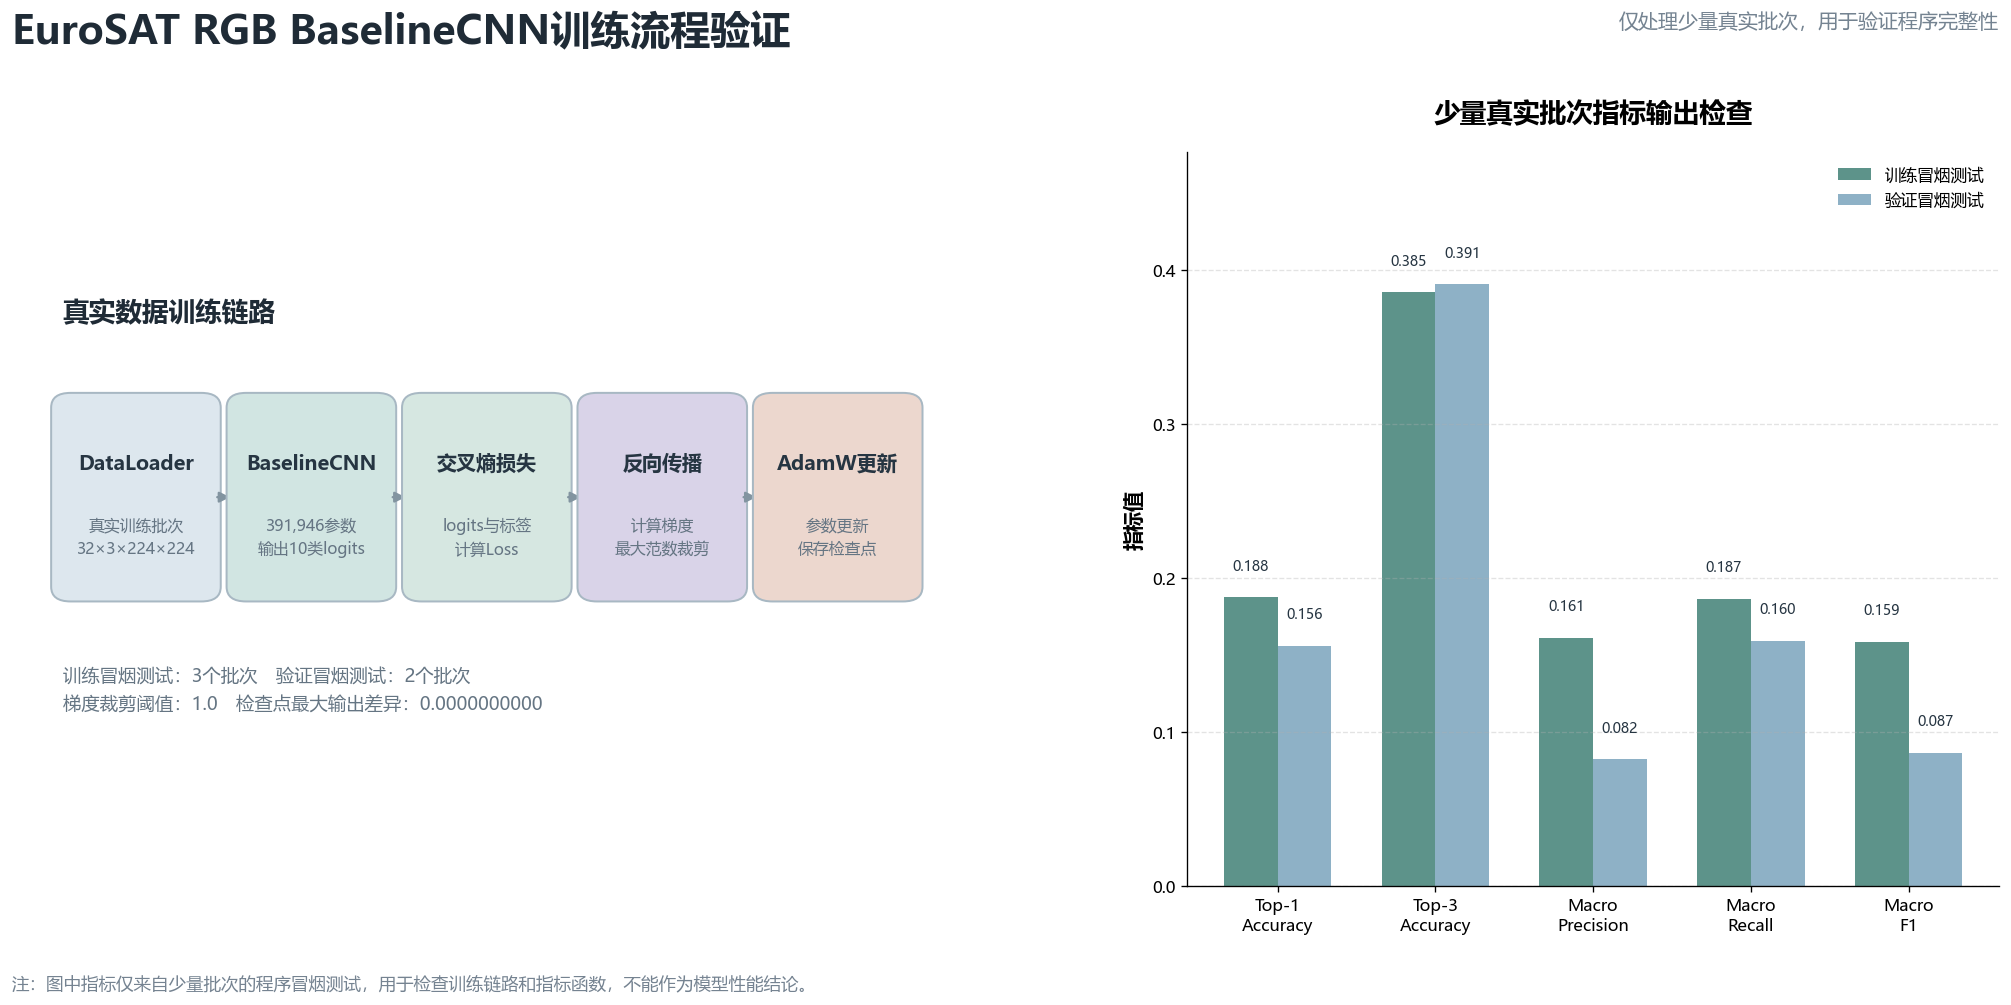

训练流程验证图已保存：12_BaselineCNN训练流程验证.png


In [18]:
# ==========================================
# 6.2.1 训练流程验证结果可视化
# ==========================================

fig = plt.figure(
    figsize=(
        18,
        9
    )
)

grid_spec = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[
        1.2,
        1.0
    ],
    left=0.05,
    right=0.96,
    top=0.82,
    bottom=0.14,
    wspace=0.20
)

ax_flow = fig.add_subplot(
    grid_spec[
        0,
        0
    ]
)

ax_metrics = fig.add_subplot(
    grid_spec[
        0,
        1
    ]
)


# ------------------------------
# 总标题
# ------------------------------
fig.text(
    0.04,
    0.95,
    "EuroSAT RGB BaselineCNN训练流程验证",
    fontsize=24,
    fontweight="bold",
    color="#1F2B36",
    va="top"
)

fig.text(
    0.96,
    0.95,
    "仅处理少量真实批次，用于验证程序完整性",
    fontsize=12,
    color="#748391",
    ha="right",
    va="top"
)


# ------------------------------
# 左侧：训练数据流
# ------------------------------
ax_flow.set_xlim(
    0,
    1
)

ax_flow.set_ylim(
    0,
    1
)

ax_flow.axis(
    "off"
)


flow_nodes = [
    {
        "x": 0.03,
        "width": 0.15,
        "title": "DataLoader",
        "detail": "真实训练批次\n32×3×224×224",
        "color": "#DDE7EE"
    },
    {
        "x": 0.21,
        "width": 0.15,
        "title": "BaselineCNN",
        "detail": "391,946参数\n输出10类logits",
        "color": "#D1E5E2"
    },
    {
        "x": 0.39,
        "width": 0.15,
        "title": "交叉熵损失",
        "detail": "logits与标签\n计算Loss",
        "color": "#D6E7E1"
    },
    {
        "x": 0.57,
        "width": 0.15,
        "title": "反向传播",
        "detail": "计算梯度\n最大范数裁剪",
        "color": "#D9D3E8"
    },
    {
        "x": 0.75,
        "width": 0.15,
        "title": "AdamW更新",
        "detail": "参数更新\n保存检查点",
        "color": "#ECD7CE"
    }
]


for node_index, node in enumerate(
    flow_nodes
):

    node_patch = FancyBboxPatch(
        (
            node[
                "x"
            ],
            0.40
        ),
        node[
            "width"
        ],
        0.26,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#A8B8C3",
        facecolor=node[
            "color"
        ]
    )

    ax_flow.add_patch(
        node_patch
    )

    ax_flow.text(
        node[
            "x"
        ]
        + node[
            "width"
        ] / 2,
        0.575,
        node[
            "title"
        ],
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#263542"
    )

    ax_flow.text(
        node[
            "x"
        ]
        + node[
            "width"
        ] / 2,
        0.475,
        node[
            "detail"
        ],
        ha="center",
        va="center",
        fontsize=9.5,
        color="#657583",
        linespacing=1.5
    )

    if node_index < len(
        flow_nodes
    ) - 1:

        arrow_start_x = (
            node[
                "x"
            ]
            + node[
                "width"
            ]
        )

        arrow_end_x = (
            flow_nodes[
                node_index + 1
            ][
                "x"
            ]
        )

        flow_arrow = FancyArrowPatch(
            (
                arrow_start_x + 0.005,
                0.53
            ),
            (
                arrow_end_x - 0.005,
                0.53
            ),
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.4,
            color="#8294A0"
        )

        ax_flow.add_patch(
            flow_arrow
        )


ax_flow.text(
    0.03,
    0.77,
    "真实数据训练链路",
    fontsize=16,
    fontweight="bold",
    color="#1F2B36"
)

ax_flow.text(
    0.03,
    0.24,
    (
        f"训练冒烟测试：{SMOKE_TRAIN_BATCHES}个批次　"
        f"验证冒烟测试：{SMOKE_VAL_BATCHES}个批次\n"
        f"梯度裁剪阈值：{GRADIENT_CLIP_MAX_NORM:.1f}　"
        f"检查点最大输出差异：{maximum_logit_difference:.10f}"
    ),
    fontsize=11,
    color="#657583",
    linespacing=1.7
)


# ------------------------------
# 右侧：少量批次指标
# ------------------------------
metric_names = [
    "Top-1\nAccuracy",
    "Top-3\nAccuracy",
    "Macro\nPrecision",
    "Macro\nRecall",
    "Macro\nF1"
]

train_metric_values = [
    smoke_train_result[
        "Top-1 Accuracy"
    ],
    smoke_train_result[
        "Top-3 Accuracy"
    ],
    smoke_train_result[
        "Macro-Precision"
    ],
    smoke_train_result[
        "Macro-Recall"
    ],
    smoke_train_result[
        "Macro-F1"
    ]
]

val_metric_values = [
    smoke_val_result[
        "Top-1 Accuracy"
    ],
    smoke_val_result[
        "Top-3 Accuracy"
    ],
    smoke_val_result[
        "Macro-Precision"
    ],
    smoke_val_result[
        "Macro-Recall"
    ],
    smoke_val_result[
        "Macro-F1"
    ]
]


metric_x = np.arange(
    len(
        metric_names
    )
)

bar_width = 0.34


train_bars = ax_metrics.bar(
    metric_x
    - bar_width / 2,
    train_metric_values,
    width=bar_width,
    color="#4F8A80",
    alpha=0.92,
    label="训练冒烟测试"
)

val_bars = ax_metrics.bar(
    metric_x
    + bar_width / 2,
    val_metric_values,
    width=bar_width,
    color="#84ABC2",
    alpha=0.92,
    label="验证冒烟测试"
)


for bar_group in [
    train_bars,
    val_bars
]:

    for bar in bar_group:

        bar_height = (
            bar.get_height()
        )

        ax_metrics.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar_height + 0.015,
            f"{bar_height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#263542"
        )


ax_metrics.set_title(
    "少量真实批次指标输出检查",
    fontsize=16,
    pad=18
)

ax_metrics.set_xticks(
    metric_x
)

ax_metrics.set_xticklabels(
    metric_names,
    fontsize=10
)

ax_metrics.set_ylabel(
    "指标值",
    fontsize=12
)

ax_metrics.set_ylim(
    0,
    max(
        max(
            train_metric_values
        ),
        max(
            val_metric_values
        ),
        0.35
    ) * 1.22
)

ax_metrics.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax_metrics.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

ax_metrics.spines[
    "top"
].set_visible(
    False
)

ax_metrics.spines[
    "right"
].set_visible(
    False
)


fig.text(
    0.04,
    0.045,
    (
        "注：图中指标仅来自少量批次的程序冒烟测试，"
        "用于检查训练链路和指标函数，不能作为模型性能结论。"
    ),
    fontsize=10.5,
    color="#758391"
)


training_flow_figure_path = (
    STEP_OUTPUT_DIR
    / "12_BaselineCNN训练流程验证.png"
)

plt.savefig(
    training_flow_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(
    f"训练流程验证图已保存："
    f"{training_flow_figure_path.name}"
)

#### 模型检查点保存与重新加载结果分析

冒烟测试模型已成功保存为检查点文件，文件大小约为4.5132 MB。该检查点不仅包含模型参数，还包含AdamW优化器状态、当前训练与验证指标、类别名称和随机种子等信息，因此其文件大小高于仅保存模型权重时的理论参数存储空间。

重新构建BaselineCNN并加载检查点后，新模型与保存前模型的状态字典键完全一致。在相同验证图像输入下，两个模型输出logits的最大绝对差异为0，说明模型参数在保存和加载过程中没有发生精度损失或字段遗漏。

该结果验证了检查点写入、读取和模型状态恢复流程的正确性，为后续正式训练中的最佳模型保存、训练中断恢复以及最终测试阶段加载最佳权重提供了可靠基础。


In [19]:
# ==========================================
# 6.2.1 保存配置、完整性检查与输出清单
# ==========================================

baseline_training_pipeline_config = {
    "步骤编号": "6.2.1",
    "步骤名称": "BaselineCNN训练流程与单轮验证",
    "生成时间": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    ),
    "项目根目录": str(
        PROJECT_ROOT
    ),
    "训练集清单": str(
        train_manifest_record[
            "文件路径"
        ].relative_to(
            PROJECT_ROOT
        )
    ),
    "验证集清单": str(
        val_manifest_record[
            "文件路径"
        ].relative_to(
            PROJECT_ROOT
        )
    ),
    "训练集样本数": len(
        train_dataset
    ),
    "验证集样本数": len(
        val_dataset
    ),
    "模型名称": "BaselineCNN",
    "模型总参数量": (
        total_parameter_count
    ),
    "可训练参数量": (
        trainable_parameter_count
    ),
    "输入形状": [
        3,
        224,
        224
    ],
    "输出类别数量": NUM_CLASSES,
    "损失函数": "CrossEntropyLoss",
    "优化器": "AdamW",
    "初始学习率": (
        BASELINE_LEARNING_RATE
    ),
    "权重衰减": (
        BASELINE_WEIGHT_DECAY
    ),
    "梯度裁剪最大范数": (
        GRADIENT_CLIP_MAX_NORM
    ),
    "最大正式训练轮数": (
        BASELINE_MAX_EPOCHS
    ),
    "批次大小": BATCH_SIZE,
    "冒烟测试训练批次": (
        SMOKE_TRAIN_BATCHES
    ),
    "冒烟测试验证批次": (
        SMOKE_VAL_BATCHES
    ),
    "正式训练是否已执行": False,
    "下一步骤": (
        "6.2.2_BaselineCNN正式训练"
    )
}


pipeline_config_path = (
    STEP_OUTPUT_DIR
    / "13_BaselineCNN训练流程配置.json"
)

with open(
    pipeline_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        baseline_training_pipeline_config,
        file,
        ensure_ascii=False,
        indent=4
    )


# ------------------------------
# 完整性检查
# ------------------------------
required_output_files = [
    STEP_OUTPUT_DIR
    / "01_训练配置继承结果.csv",

    STEP_OUTPUT_DIR
    / "02_训练集与验证集清单定位结果.csv",

    STEP_OUTPUT_DIR
    / "03_Dataset构建结果.csv",

    STEP_OUTPUT_DIR
    / "04_DataLoader首批检查.csv",

    STEP_OUTPUT_DIR
    / "05_BaselineCNN模型结构检查.csv",

    STEP_OUTPUT_DIR
    / "06_真实批次前向反向传播检查.csv",

    STEP_OUTPUT_DIR
    / "07_少量真实批次训练验证结果.csv",

    STEP_OUTPUT_DIR
    / "08_冒烟测试训练混淆矩阵.npy",

    STEP_OUTPUT_DIR
    / "09_冒烟测试验证混淆矩阵.npy",

    STEP_OUTPUT_DIR
    / "10_BaselineCNN流程验证检查点.pt",

    STEP_OUTPUT_DIR
    / "11_模型检查点保存与加载检查.csv",

    STEP_OUTPUT_DIR
    / "12_BaselineCNN训练流程验证.png",

    STEP_OUTPUT_DIR
    / "13_BaselineCNN训练流程配置.json"
]


integrity_records = [
    {
        "检查项目": "统一配置继承",
        "检查结果": (
            "6.1.1、6.1.2和6.1.3配置读取成功"
        ),
        "是否通过": (
            RUNTIME_CONFIG_PATH.exists()
            and EVALUATION_CONFIG_PATH.exists()
            and TRAINING_CONFIG_PATH.exists()
        )
    },
    {
        "检查项目": "训练集样本数量",
        "检查结果": len(
            train_dataset
        ),
        "是否通过": (
            len(
                train_dataset
            ) == 18900
        )
    },
    {
        "检查项目": "验证集样本数量",
        "检查结果": len(
            val_dataset
        ),
        "是否通过": (
            len(
                val_dataset
            ) == 4050
        )
    },
    {
        "检查项目": "DataLoader张量尺寸",
        "检查结果": str(
            tuple(
                train_images.shape
            )
        ),
        "是否通过": (
            tuple(
                train_images.shape[1:]
            )
            == (
                3,
                224,
                224
            )
        )
    },
    {
        "检查项目": "BaselineCNN参数量",
        "检查结果": (
            f"{total_parameter_count:,}"
        ),
        "是否通过": (
            total_parameter_count
            == 391946
        )
    },
    {
        "检查项目": "真实批次输出尺寸",
        "检查结果": str(
            tuple(
                real_logits.shape
            )
        ),
        "是否通过": (
            real_logits.shape[
                1
            ]
            == NUM_CLASSES
        )
    },
    {
        "检查项目": "真实批次损失",
        "检查结果": float(
            real_batch_loss
        ),
        "是否通过": bool(
            torch.isfinite(
                real_batch_loss
            )
        )
    },
    {
        "检查项目": "真实批次参数更新",
        "检查结果": (
            f"{changed_parameter_tensor_count}"
            f"个参数张量发生更新"
        ),
        "是否通过": (
            changed_parameter_tensor_count
            > 0
        )
    },
    {
        "检查项目": "梯度裁剪后范数",
        "检查结果": (
            f"{gradient_norm_after_clip:.8f}"
        ),
        "是否通过": (
            gradient_norm_after_clip
            <= GRADIENT_CLIP_MAX_NORM
            + 1e-5
        )
    },
    {
        "检查项目": "训练函数执行",
        "检查结果": (
            f"{smoke_train_result['处理批次数']}"
            f"个批次"
        ),
        "是否通过": (
            smoke_train_result[
                "处理批次数"
            ]
            == SMOKE_TRAIN_BATCHES
        )
    },
    {
        "检查项目": "验证函数执行",
        "检查结果": (
            f"{smoke_val_result['处理批次数']}"
            f"个批次"
        ),
        "是否通过": (
            smoke_val_result[
                "处理批次数"
            ]
            == SMOKE_VAL_BATCHES
        )
    },
    {
        "检查项目": "检查点重新加载一致性",
        "检查结果": (
            f"最大差异"
            f"{maximum_logit_difference:.10f}"
        ),
        "是否通过": (
            maximum_logit_difference
            < 1e-7
        )
    },
    {
        "检查项目": "必要输出文件",
        "检查结果": (
            f"{sum(path.exists() for path in required_output_files)}"
            f"/{len(required_output_files)}个已生成"
        ),
        "是否通过": all(
            path.exists()
            for path in required_output_files
        )
    }
]


integrity_check_df = pd.DataFrame(
    integrity_records
)


integrity_check_path = (
    STEP_OUTPUT_DIR
    / "14_BaselineCNN训练流程完整性检查.csv"
)

integrity_check_df.to_csv(
    integrity_check_path,
    index=False,
    encoding="utf-8-sig"
)


all_checks_passed = bool(
    integrity_check_df[
        "是否通过"
    ].all()
)


print(
    "6.2.1 BaselineCNN训练流程完整性检查："
)

display(
    integrity_check_df
)


assert all_checks_passed, (
    "6.2.1完整性检查未全部通过。"
)


# ------------------------------
# 输出文件清单
# ------------------------------
manifest_path = (
    STEP_OUTPUT_DIR
    / "15_输出文件清单.csv"
)

manifest_path.touch(
    exist_ok=True
)


output_file_records = []

for output_path in sorted(
    STEP_OUTPUT_DIR.iterdir()
):

    if not output_path.is_file():
        continue

    output_file_records.append({
        "文件名称": output_path.name,
        "文件类型": (
            output_path.suffix.lower()
        ),
        "文件大小_KB": round(
            output_path.stat().st_size
            / 1024,
            2
        ),
        "相对路径": str(
            output_path.relative_to(
                PROJECT_ROOT
            )
        )
    })


output_manifest_df = pd.DataFrame(
    output_file_records
)

output_manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n6.2.1 BaselineCNN训练流程与单轮验证执行完成。"
)

print(
    f"所有结果已保存至：\n"
    f"{STEP_OUTPUT_DIR}"
)

print(
    "\n本步骤未进行30轮正式训练。"
)

print(
    "下一步骤："
    "6.2.2_BaselineCNN正式训练.ipynb"
)

print(
    "\n输出文件清单："
)

display(
    output_manifest_df
)

6.2.1 BaselineCNN训练流程完整性检查：


,检查项目,检查结果,是否通过
0,统一配置继承,6.1.1、6.1.2和6.1.3配置读取成功,True
1,训练集样本数量,18900,True
2,验证集样本数量,4050,True
3,DataLoader张量尺寸,"(32, 3, 224, 224)",True
4,BaselineCNN参数量,"391,946",True
5,真实批次输出尺寸,"(32, 10)",True
6,真实批次损失,2.467463,True
7,真实批次参数更新,18个参数张量发生更新,True
8,梯度裁剪后范数,0.99999952,True
9,训练函数执行,3个批次,True



6.2.1 BaselineCNN训练流程与单轮验证执行完成。
所有结果已保存至：
d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证

本步骤未进行30轮正式训练。
下一步骤：6.2.2_BaselineCNN正式训练.ipynb

输出文件清单：


,文件名称,文件类型,文件大小_KB,相对路径
0,01_训练配置继承结果.csv,.csv,0.34,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\01_训练配置继承结果.csv
1,02_训练集与验证集清单定位结果.csv,.csv,0.33,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\02_训练集与验证集清单定位结果.csv
2,03_Dataset构建结果.csv,.csv,0.18,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\03_Dataset构建结果.csv
3,04_DataLoader首批检查.csv,.csv,0.73,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\04_DataLoader首批检查.csv
4,05_BaselineCNN模型结构检查.csv,.csv,0.22,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\05_BaselineCNN模型结构检查.csv
5,06_真实批次前向反向传播检查.csv,.csv,0.48,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\06_真实批次前向反向传播检查.csv
6,07_少量真实批次训练验证结果.csv,.csv,0.38,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\07_少量真实批次训练验证结果.csv
7,08_冒烟测试训练混淆矩阵.npy,.npy,0.91,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\08_冒烟测试训练混淆矩阵.npy
8,09_冒烟测试验证混淆矩阵.npy,.npy,0.91,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\09_冒烟测试验证混淆矩阵.npy
9,10_BaselineCNN流程验证检查点.pt,.pt,4621.54,results\06_模型训练与优化\6.2.1_BaselineCNN训练流程与单轮验证\10_BaselineCNN流程验证检查点.pt


#### BaselineCNN训练流程完整性小结

本步骤完成了BaselineCNN正式训练前的完整流程验证。训练配置、评价配置与随机性设置均成功继承，训练集和验证集样本数量正确，DataLoader能够稳定输出`3×224×224`的标准化图像张量，模型参数量保持为391,946。

在真实EuroSAT批次上，模型能够顺利完成前向传播、交叉熵损失计算、反向传播、梯度裁剪和AdamW参数更新。模型输出尺寸正确，损失数值有限，所有可训练参数均能够获得梯度并发生更新。检查点保存后重新加载所得输出与原模型完全一致，证明模型状态持久化流程可靠。

完整性检查中的所有项目均已通过，所需结果文件全部成功生成。本步骤仅执行少量批次的程序冒烟测试，没有进行30轮正式训练，因此当前指标不能作为BaselineCNN最终分类性能。完成类别均衡的冒烟验证后，即可进入下一步骤`6.2.2_BaselineCNN正式训练`。
